<a href="https://colab.research.google.com/github/DarkWorldCoder/LearningAI/blob/master/Micrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [254]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random

In [255]:
def f(x):
  return 3 *x**2-4 *x +5

In [256]:
f(3.0)

20.0

In [257]:
xs=np.arange(-5,5,0.25)

In [258]:
ys = f(xs)

In [259]:
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

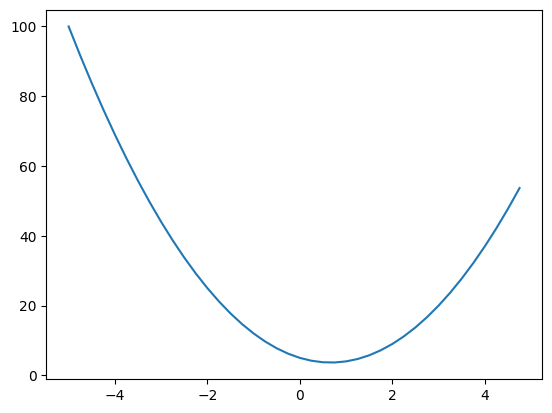

In [260]:
plt.plot(xs,ys)

In [261]:
 h = 0.00000001
 x = 3.0
fx= (f(x+h) - f(x))/h

In [262]:
fx

14.00000009255109

In [263]:
a = 2.0
b = -3.0
c = 10
d = a * b +c

In [264]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0
d1 = a*b +c
a +=h

d2 = a * b + c
print("slope",(d2-d1)/h)

slope -3.000000000010772


In [277]:
class Value:
  def __init__(self,data,_children=(),_op="",label=''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self._backward = lambda: None
    self.label = label
    self.grad = 0.0

  def __repr__(self):
    return f"Value(data={self.data})"
  def __pow__(self,other):
    assert isinstance(other,(int,float)),"only support int/float"
    out = Value(self.data**other,(self,),"**")

    def _backward():
      self.grad += (other * self.data**(other-1)) * out.grad

    out._backward = _backward
    return out
  def __neg__(self):
    return self * -1
  def __sub__(self,other):
    return self + (-other)

  def __add__(self,other):
    other = other if isinstance(other,Value) else Value(other)
    out = Value(self.data + other.data,(self,other),"+")
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    return out
  def __rmul__(self,other):
    return self * other
  def __radd__(self,other):
    return self + other
  def __rsub__(self,other):
    return other + (-self)
  def __truediv__(self,other):
    return self * other**-1
  def __mul__(self,other):
    other = other if isinstance(other,Value) else Value(other)
    out = Value(self.data * other.data,(self,other),"*")
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x)-1) / (math.exp(2*x)+1)
    out = Value(t,(self,),"tanh")
    def _backward():
      self.grad += (1-t**2) * out.grad
    out._backward = _backward
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x),(self,),"exp")

    def _backward():
      self.grad += out.data * out.grad
    out._backward = _backward
    return out



  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      visited.add(v)
      for child in v._prev:
        if child not in visited:
          build_topo(child)
      topo.append(v)
    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

a = Value(2.0,label="a")
b = Value(-3.0,label="b")
c = Value(10.0,label="c")
e =  a* b; e.label = "e";
d = e + c ;d.label="d";
f = Value(-2.0,label="f")

In [278]:
from graphviz import Digraph
def trace(root):
  nodes,edges = set(),set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child,v))
        build(child)
  build(root)
  return nodes,edges

def draw_dot(root):
  dot = Digraph(format="svg",graph_attr={"rankdir":"LR"})
  nodes,edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    dot.node(name=uid,label="{%s| data %.4f | grad %.4f}" % (n.label,n.data,n.grad),shape="record")
    if n._op:
      dot.node(name=uid+n._op,label=n._op)
      dot.edge(uid+n._op,uid)
  for n1,n2 in edges:
    dot.edge(str(id(n1)),str(id(n2))+n2._op)
  return dot

In [279]:
a = Value(1.0)
a*1

Value(data=1.0)

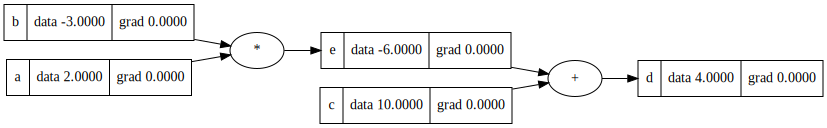

In [280]:
draw_dot(d)

plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)))

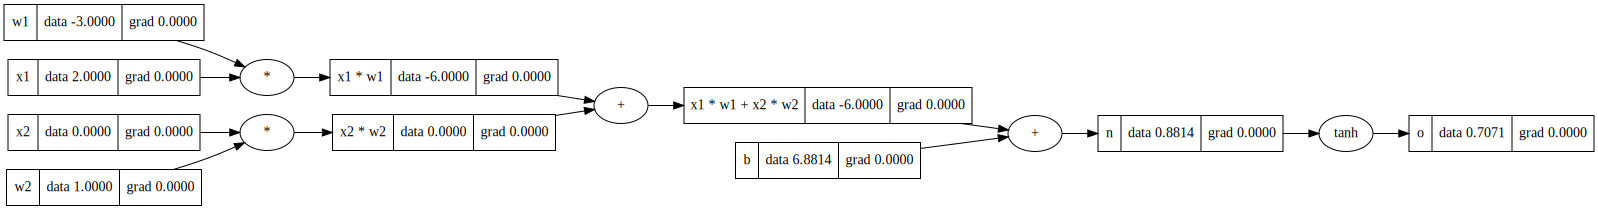

In [281]:
x1 = Value(2.0,label="x1")
x2 = Value(0.0,label="x2")
w1 = Value(-3.0,label="w1")
w2 = Value(1.0,label="w2")
b = Value(6.88137358,label="b")
x1w1 = x1 *w1;x1w1.label="x1 * w1"
x2w2 = x2 *w2;x2w2.label="x2 * w2"
x1w1x2w2 = x1w1 + x2w2;x1w1x2w2.label="x1 * w1 + x2 * w2"
n = x1w1x2w2 + b;n.label="n"
o = n.tanh();o.label="o"
draw_dot(o)


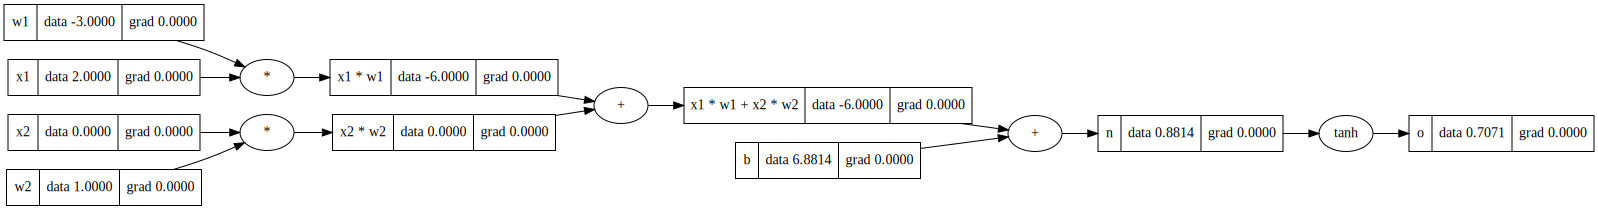

In [282]:
draw_dot(o)

In [300]:
class Neuron:
  def __init__(self,nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self,x):
    act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:
  def __init__(self,nin,nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self,x):
    outs = [n(x) for n in self.neurons]

    return outs[0] if len(outs)==1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
  def __init__(self,nin,nouts):
    sz = [nin] + nouts
    print(sz)
    self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [ p for layer in self.layers for p in layer.parameters()]



In [301]:
x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)


[3, 4, 4, 1]


Value(data=-0.7545014229837739)

In [303]:
n.parameters()

[Value(data=-0.1371691611195638),
 Value(data=0.22674804102312351),
 Value(data=-0.9028420843831744),
 Value(data=-0.3211279684561317),
 Value(data=-0.93828729147272),
 Value(data=-0.888790186433063),
 Value(data=0.7933993451221282),
 Value(data=0.8438837950001565),
 Value(data=0.31857693075016313),
 Value(data=0.31641217229968777),
 Value(data=0.48932127665759384),
 Value(data=0.2824685407432168),
 Value(data=-0.2795664707599188),
 Value(data=0.9836880201529958),
 Value(data=-0.7933958732099498),
 Value(data=0.020065797423491016),
 Value(data=-0.4582863554766976),
 Value(data=-0.6618184537712852),
 Value(data=-0.568485914940307),
 Value(data=-0.1918456375655091),
 Value(data=0.8268026329442495),
 Value(data=-0.5080083556781803),
 Value(data=0.45923411339925146),
 Value(data=0.6925926469379995),
 Value(data=0.5850537151074995),
 Value(data=0.27408325261671873),
 Value(data=0.6207282253597417),
 Value(data=0.2245343875250907),
 Value(data=-0.28023949936905357),
 Value(data=0.47676857588

In [304]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys = [1.0,-1.0,-1.0,1.0]


[Value(data=-0.7545014229837739),
 Value(data=0.2262748324923484),
 Value(data=-0.6592773560718169),
 Value(data=-0.5087415789423592)]

In [338]:
ypred = [n(x) for x in xs]

loss = sum(((yout-ygt)**2 for ygt , yout in zip(ys,ypred)))
loss

Value(data=0.0038708824697915763)

In [339]:
loss.backward()

In [340]:
for p in n.parameters():
  p.data += -0.01 * p.grad

In [342]:
ypred

[Value(data=0.9827096072123525),
 Value(data=-0.9771546747147782),
 Value(data=-0.9478749006474281),
 Value(data=0.9817519886799313)]